## Tasks To Perform

#### 1. Load And Explore The Dataset

In [1]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets/PCA Dataset.csv")

##### First Five Rows

In [2]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Quiz_Score,Internal_Marks,Practical_Score,Midterm_Score,Previous_Sem_Marks,Final_Marks
0,S001,4.9,92.8,75.6,77.9,78.6,77.3,64.3,61.2,76.5
1,S002,2.6,57.9,60.9,52.2,58.8,59.6,53.0,51.7,61.7
2,S003,3.5,90.8,91.7,86.6,77.1,77.2,77.6,78.5,73.6
3,S004,5.1,84.2,96.2,77.4,96.9,91.2,98.0,77.0,87.9
4,S005,3.0,60.0,49.2,41.9,61.6,46.3,35.0,40.2,60.0


##### Number Of Rows And Columns

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 150, Columns: 10


##### Names Of Columns

In [4]:
print("Names Of Columns:")
for i in df.columns.tolist():
    print(i)

Names Of Columns:
Student_ID
Study_Hours
Attendance
Assignment_Score
Quiz_Score
Internal_Marks
Practical_Score
Midterm_Score
Previous_Sem_Marks
Final_Marks


##### Basic Statistical Description

In [5]:
print("Statistical Description Of Data:")
df.describe()

Statistical Description Of Data:


,Study_Hours,Attendance,Assignment_Score,Quiz_Score,Internal_Marks,Practical_Score,Midterm_Score,Previous_Sem_Marks,Final_Marks
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000,150.000000,150.000000
mean,4.714000,77.592667,71.712667,69.156667,72.996000,71.43400,68.792667,65.970667,72.952667
std,1.463059,9.963121,12.546484,12.391751,10.415482,10.79599,13.602655,12.177637,12.658841
min,1.500000,55.000000,43.800000,36.400000,46.700000,45.20000,35.000000,40.200000,43.100000
25%,3.800000,70.275000,63.225000,60.650000,66.050000,63.80000,59.175000,56.900000,62.400000
50%,4.700000,77.900000,71.400000,69.650000,72.650000,72.15000,68.200000,66.450000,72.100000
75%,5.475000,84.175000,79.925000,78.825000,80.275000,78.47500,78.550000,74.975000,82.150000
max,8.500000,98.000000,100.000000,100.000000,98.600000,100.00000,100.000000,100.000000,100.000000


##### Q.Identify The Feature That Should Not Be Used For PCA And Explain Why?

###### The feature that should not be used for Principal Component Analysis (PCA) is Student_ID.
###### We Should Not Use Categorical Features For Dimensional Reduction Technique As It is used for dimensionality reduction designed for quantitative , numerical data.

#### 2.Data Preprocessing

In [2]:
df.isnull().sum()

Student_ID            0
Study_Hours           0
Attendance            0
Assignment_Score      0
Quiz_Score            0
Internal_Marks        0
Practical_Score       0
Midterm_Score         0
Previous_Sem_Marks    0
Final_Marks           0
dtype: int64

In [3]:
df[df['Previous_Sem_Marks']<50].shape

(17, 10)

In [4]:
def cal_grade(col):
    conditions = [df[col] >= 90,df[col] >= 75,df[col] >= 60]
    choices = ['A','B','C']
    df['Grade'] = np.select(conditions,choices,default='D')

In [5]:
cal_grade("Previous_Sem_Marks")

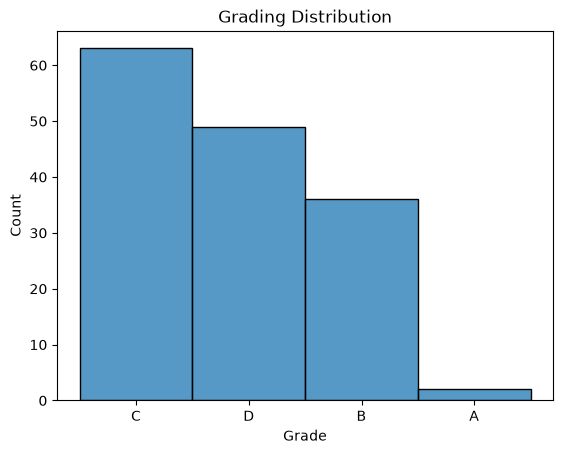

In [6]:
sns.histplot(data=df,x='Grade',binwidth=10)
plt.title("Grading Distribution")
plt.show()

In [7]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Quiz_Score,Internal_Marks,Practical_Score,Midterm_Score,Previous_Sem_Marks,Final_Marks,Grade
0,S001,4.9,92.8,75.6,77.9,78.6,77.3,64.3,61.2,76.5,C
1,S002,2.6,57.9,60.9,52.2,58.8,59.6,53.0,51.7,61.7,D
2,S003,3.5,90.8,91.7,86.6,77.1,77.2,77.6,78.5,73.6,B
3,S004,5.1,84.2,96.2,77.4,96.9,91.2,98.0,77.0,87.9,B
4,S005,3.0,60.0,49.2,41.9,61.6,46.3,35.0,40.2,60.0,D


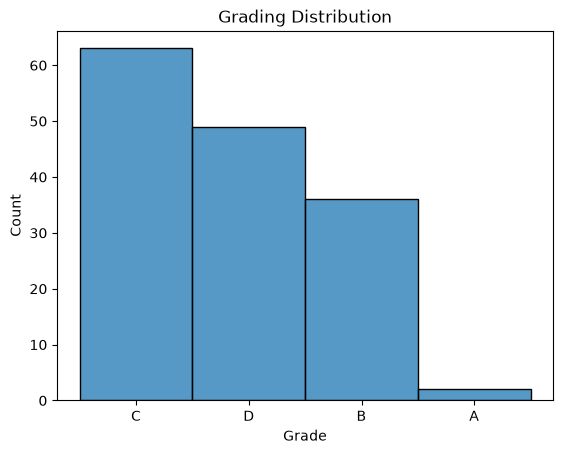

In [8]:
sns.histplot(data=df,x='Grade',binwidth=10)
plt.title("Grading Distribution")
plt.show()

In [9]:
def plotgraph(col):
    sns.histplot(data=df, x=col, kde=True)
    plt.show()

In [10]:
df['Grade'].value_counts()

Grade
C    63
D    49
B    36
A     2
Name: count, dtype: int64

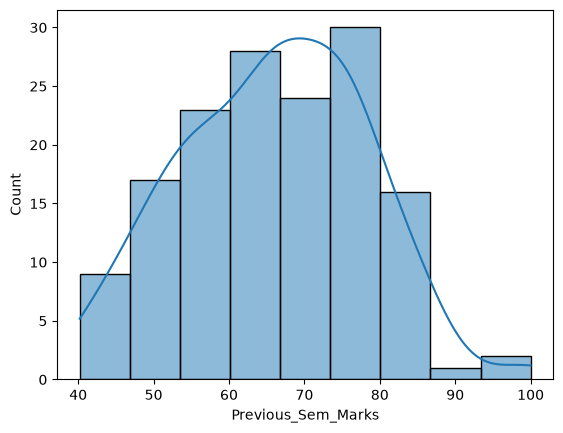

In [11]:
plotgraph('Previous_Sem_Marks')

#### 3.Data Training

In [12]:
X = df.iloc[:,1:10]
Y = df.iloc[:,-1]

In [13]:
X.head()

,Study_Hours,Attendance,Assignment_Score,Quiz_Score,Internal_Marks,Practical_Score,Midterm_Score,Previous_Sem_Marks,Final_Marks
0,4.9,92.8,75.6,77.9,78.6,77.3,64.3,61.2,76.5
1,2.6,57.9,60.9,52.2,58.8,59.6,53.0,51.7,61.7
2,3.5,90.8,91.7,86.6,77.1,77.2,77.6,78.5,73.6
3,5.1,84.2,96.2,77.4,96.9,91.2,98.0,77.0,87.9
4,3.0,60.0,49.2,41.9,61.6,46.3,35.0,40.2,60.0


In [14]:
Y.head()

0    C
1    D
2    B
3    B
4    D
Name: Grade, dtype: str

In [15]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,42)

In [16]:
X_test.head()

,Study_Hours,Attendance,Assignment_Score,Quiz_Score,Internal_Marks,Practical_Score,Midterm_Score,Previous_Sem_Marks,Final_Marks
73,3.9,88.4,76.5,66.2,67.5,79.7,72.7,75.3,88.4
18,5.4,92.8,90.1,77.2,77.1,89.5,90.6,68.6,93.7
118,6.3,91.9,95.9,88.4,89.0,87.6,87.3,74.9,85.8
78,4.3,94.9,81.0,80.1,89.5,69.2,74.6,76.7,85.8
76,7.4,72.7,79.3,85.7,68.8,76.7,79.5,57.9,76.3


In [17]:
Y_train.head()

22    B
15    D
65    B
11    C
42    C
Name: Grade, dtype: str

#### 4.Feature Selection And Standardization

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train_df = pd.DataFrame(X_train, columns=df.columns[1:10])

##### First Five Rows Of The Standardized Dataset

In [21]:
print("Data After Standardization:")
X_train_df.head()

Data After Standardization:


,Study_Hours,Attendance,Assignment_Score,Quiz_Score,Internal_Marks,Practical_Score,Midterm_Score,Previous_Sem_Marks,Final_Marks
0,0.497243,1.990690,1.182802,1.488335,1.641449,1.316237,1.060848,1.452370,1.669884
1,-1.257732,-0.925949,-1.009014,-1.506351,-1.885129,-0.287394,-0.842394,-1.481820,-0.717134
2,1.409829,1.819714,1.198918,0.127114,1.220504,0.219501,0.953117,0.755297,0.682152
3,-0.064349,1.075469,0.449510,0.999897,1.314048,0.984451,1.463043,0.528343,1.406489
4,-0.696140,-0.493482,-0.686688,0.615552,-0.360375,-0.397989,-0.181646,0.431077,-0.931143


##### Need Of Standardization Before Applying PCA

###### Since Each Principal Components Have Different Set Of Values And Different Variance Factor , Thus iit is quite difficult for us to analyse data on the same scale.to overcome this problem , we transform all components on the same factor transforming them into a mean centered data (mean=0) and standard deviation(sd=1).

#### 5.Applying PCA

In [22]:
from sklearn.decomposition import PCA

In [23]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train,Y_train)
X_test_trf = pca.transform(X_test)

In [24]:
print(X_train_trf.shape)

(120, 9)


In [41]:
print(f"{'Principal Component':^20}  {'Explained Variance(%)':^22}")
for i in range(len(pca.explained_variance_ratio_)):
    print(f"{f'PC{i+1}':^20}  "f"{pca.explained_variance_ratio_[i] * 100:^22.2f}")

Principal Component   Explained Variance(%) 
        PC1                   68.71         
        PC2                    8.44         
        PC3                    4.80         
        PC4                    4.33         
        PC5                    3.40         
        PC6                    3.27         
        PC7                    2.82         
        PC8                    2.33         
        PC9                    1.91         


In [40]:
cumulative = pca.explained_variance_ratio_.cumsum()
print(f"{'Principal Component':^20}  {'Cumulative Variance(%)':^22}")
for i in range(len(cumulative)):
    print(f"{f'PC{i+1}':^20} "f"{cumulative[i] * 100:^22.2f}")

Principal Component   Cumulative Variance(%)
        PC1                  68.71         
        PC2                  77.14         
        PC3                  81.94         
        PC4                  86.27         
        PC5                  89.67         
        PC6                  92.93         
        PC7                  95.76         
        PC8                  98.09         
        PC9                  100.00        


In [42]:
variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance(%)': pca.explained_variance_ratio_.round(4)*100
    })
variance['Cumulative Variance(%)'] = variance['Explained Variance(%)'].cumsum()
variance

,Principal Component,Explained Variance(%),Cumulative Variance(%)
0,PC1,68.71,68.71
1,PC2,8.44,77.15
2,PC3,4.80,81.95
3,PC4,4.33,86.28
4,PC5,3.40,89.68
5,PC6,3.27,92.95
6,PC7,2.82,95.77
7,PC8,2.33,98.10
8,PC9,1.91,100.01


#### 6.Visualize Explained Variance

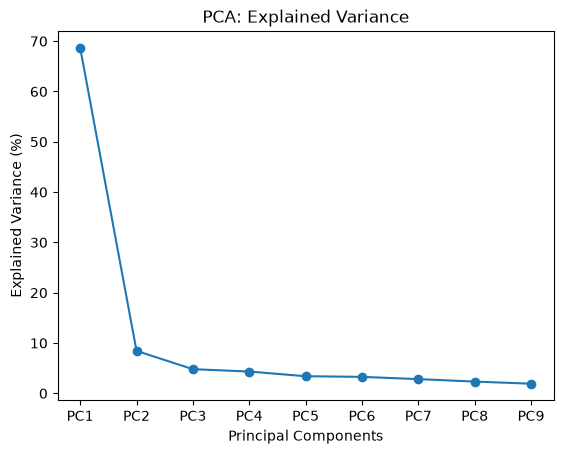

In [43]:
plt.plot(variance['Principal Component'],pca.explained_variance_ratio_ * 100,marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance (%)')
plt.title('PCA: Explained Variance')
plt.xticks(variance['Principal Component'])
plt.show()

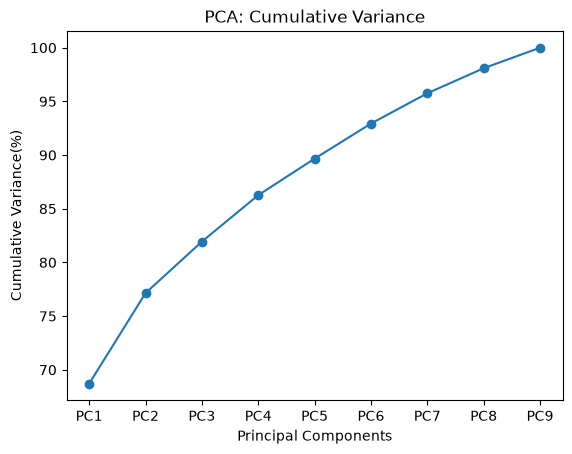

In [44]:
plt.plot(variance['Principal Component'],np.cumsum(pca.explained_variance_ratio_) * 100,marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Variance(%)')
plt.title('PCA: Cumulative Variance')
plt.xticks(variance['Principal Component'])
plt.show()

#### 7.Select Principal Components

In [63]:
cumulative = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative >= 0.95).argmax() + 1

print(f"{'Item':<23} {'Result':>9}")
print(f"{'Original Number Of Features':<24} {X_train_trf.shape[1]}")
print(f"{'Required Variance':<22}     {95}%")
print(f"{'Required PCs':<20} {n_components:>8}")
print(f"{'Variance retained':<20} {cumulative[n_components-1] * 100:>9.2f}%")

Item                       Result
Original Number Of Features 9
Required Variance          95%
Required PCs                7
Variance retained        95.76%


#### 8. Transform the Dataset

In [64]:
pca = PCA(n_components=2)

In [65]:
X_train_trf = pca.fit_transform(X_train,Y_train)
X_test_trf = pca.transform(X_test)

##### First Five Rows Of The Transformed Dataset

In [70]:
X_transformed_df = pd.DataFrame(X_train_trf, columns=[f'PC{i+1}' for i in range(X_train_trf.shape[1])])

##### Shape Of The Transformed Dataset

In [82]:
print(f"Original:{df.shape[0]} x {X_train.shape[1]}")
print(f"After PCA:{df.shape[0]} x {X_transformed_df.shape[1]}")

Original:150 x 9
After PCA:150 x 2


#### 9.Visualize the PCA Result

In [83]:
import plotly.express as px

In [91]:
X_transformed_df

,PC1,PC2
0,4.117921,-0.987589
1,-3.270422,0.252016
2,2.714613,-0.186668
3,2.781106,-0.763311
4,-0.873850,-0.459116
...,...,...
115,-2.158058,-0.592773
116,-2.165201,0.698430
117,1.405194,0.370225
118,-1.549421,-1.100006


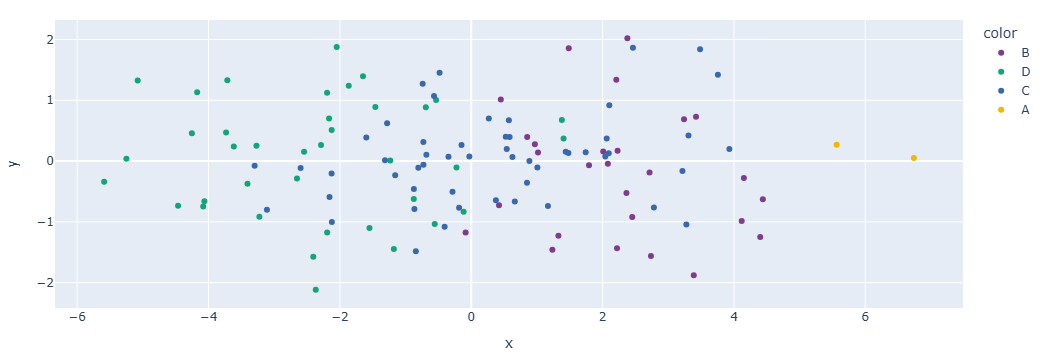

In [93]:
fig = px.scatter(x=X_train_trf[:,0],y=X_train_trf[:,1],color=Y_train,color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(margin=dict(l=20,r=20,t=20,b=20))
fig.show()

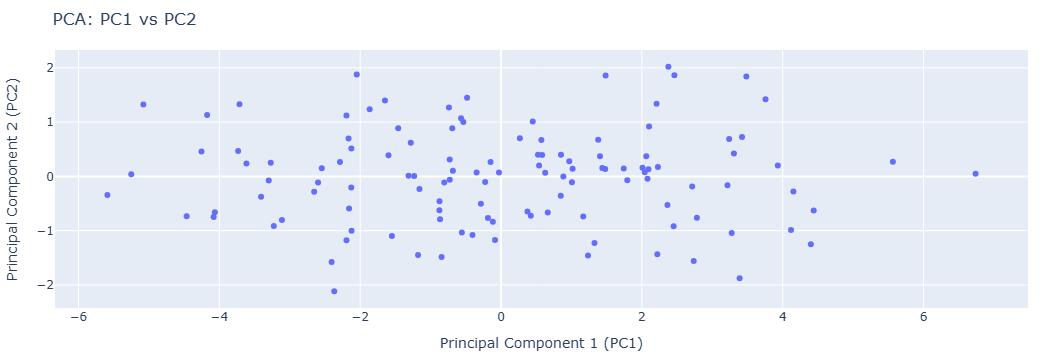

In [95]:
# ALl the points having nine dimensions earlier is reduced into a two dimensional space , which is easy for us to visualise and understand.
fig = px.scatter(x=X_train_trf[:, 0],y=X_train_trf[:, 1],title="PCA: PC1 vs PC2",labels={"x": "Principal Component 1 (PC1)","y": "Principal Component 2 (PC2)"})
fig.update_layout(margin=dict(l=20, r=20, t=50, b=20))
fig.show()

#### 10.Result And Analysis

##### How Many Features Were Present Before PCA? => 9

##### How Many Principal Components Were Required To Retain 95% Variance ? => 7

##### What Percentage Of Variance Is Explained By PC1? => 62.35%

In [107]:
print(f"{pca.explained_variance_[0].round(3)*10} %")

62.35 %


##### Which Principal Component Explains The Maximum Variance? => PC1(Study_Hours)

In [108]:
print(f"{pca.explained_variance_.max().round(3)*10} %")

62.35 %


##### How much dimensionality reduction was achieved? - let's formulate this

In [109]:
Data_Dimensions = X_train.shape[1]
PCA_Dimensions = X_train_trf.shape[1]
Reduced = ((Data_Dimensions - PCA_Dimensions) / Data_Dimensions)*100

print(f"Original Number Of Dimensions: {Data_Dimensions}")
print(f"Reduced Number Of Dimensions: {PCA_Dimensions}")
print(f"Dimensionality Reduction: {Reduced:.2f}%")

Original Number Of Dimensions: 9
Reduced Number Of Dimensions: 2
Dimensionality Reduction: 77.78%


##### Was there any information loss after PCA? Explain Using The Variance Retained.

In [111]:
pca = PCA(n_components=7)
X_train_trf = pca.fit_transform(X_train,Y_train)
X_test_trf = pca.transform(X_test)

In [117]:
variance_retained = pca.explained_variance_ratio_.sum() * 100
information_loss = 100 - variance_retained

print(f"Variance Retained : {variance_retained:.2f}%")
print(f"Information Lost  : {information_loss:.2f}%")

Variance Retained : 95.76%
Information Lost  : 4.24%
